# Forecast Energy Consumption Using LSTM Networks

## Dataset
Individual Household Electric Power Consumption (UCI)

## Objective
Forecast household energy consumption using an LSTM model.

## Workflow
1. Data Loading
2. Data Cleaning
3. EDA
4. Feature Engineering
5. Data Splitting
6. Scaling
7. Sliding Window
8. LSTM Model
9. Evaluation
10. Residual Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/household_power_consumption.txt',sep=';',na_values='?')

In [3]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
print(df.shape)
print(df.columns)
print(df.describe(include='all'))


(2075259, 9)
Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='str')
              Date      Time  Global_active_power  Global_reactive_power  \
count      2075259   2075259         2.049280e+06           2.049280e+06   
unique        1442      1440                  NaN                    NaN   
top     17/12/2006  17:24:00                  NaN                    NaN   
freq          1440      1442                  NaN                    NaN   
mean           NaN       NaN         1.091615e+00           1.237145e-01   
std            NaN       NaN         1.057294e+00           1.127220e-01   
min            NaN       NaN         7.600000e-02           0.000000e+00   
25%            NaN       NaN         3.080000e-01           4.800000e-02   
50%            NaN       NaN         6.020000e-01           1.000000e-01   
75%            NaN       NaN         

In [ ]:
df.isnull().sum()

In [5]:
df.dtypes

Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

In [6]:
df["datetime"] = pd.to_datetime(df["Date"]+" "+df["Time"],dayfirst=True)
df["datetime"]

0         2006-12-16 17:24:00
1         2006-12-16 17:25:00
2         2006-12-16 17:26:00
3         2006-12-16 17:27:00
4         2006-12-16 17:28:00
                  ...        
2075254   2010-11-26 20:58:00
2075255   2010-11-26 20:59:00
2075256   2010-11-26 21:00:00
2075257   2010-11-26 21:01:00
2075258   2010-11-26 21:02:00
Name: datetime, Length: 2075259, dtype: datetime64[us]

In [7]:
df.set_index("datetime",inplace=True)

In [8]:
df.index

DatetimeIndex(['2006-12-16 17:24:00', '2006-12-16 17:25:00',
               '2006-12-16 17:26:00', '2006-12-16 17:27:00',
               '2006-12-16 17:28:00', '2006-12-16 17:29:00',
               '2006-12-16 17:30:00', '2006-12-16 17:31:00',
               '2006-12-16 17:32:00', '2006-12-16 17:33:00',
               ...
               '2010-11-26 20:53:00', '2010-11-26 20:54:00',
               '2010-11-26 20:55:00', '2010-11-26 20:56:00',
               '2010-11-26 20:57:00', '2010-11-26 20:58:00',
               '2010-11-26 20:59:00', '2010-11-26 21:00:00',
               '2010-11-26 21:01:00', '2010-11-26 21:02:00'],
              dtype='datetime64[us]', name='datetime', length=2075259, freq=None)

In [9]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [10]:
type(df.index)

pandas.DatetimeIndex

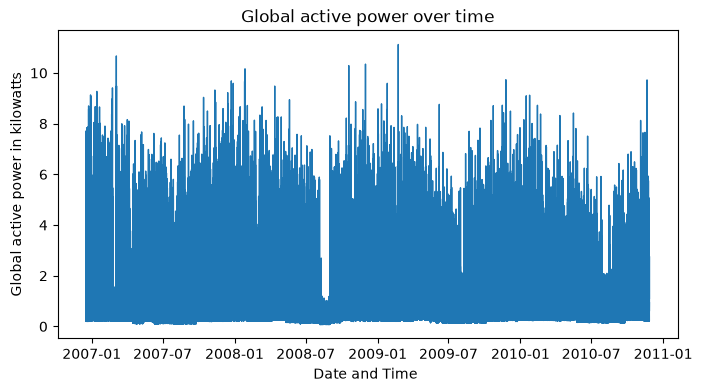

In [11]:
plt.figure(figsize=(8,4))
plt.plot(df['Global_active_power'],linewidth=1)
plt.title("Global active power over time")
plt.xlabel("Date and Time ")
plt.ylabel("Global active power in kilowatts")
plt.show()

In [12]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [13]:
numerical_cols = df.select_dtypes(include="number").columns

for col in numerical_cols:
    df[col]=df[col].interpolate(method="time")

In [14]:
df.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [15]:
numeric_df=df.select_dtypes(include="number")
hourly_df=numeric_df.resample('h').mean()
print(hourly_df.shape)

(34589, 7)


In [16]:
hourly_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [17]:
week_minute = df.loc["2007-01-01":"2007-01-07"]

week_hourly = hourly_df.loc["2007-01-01":"2007-01-07"]

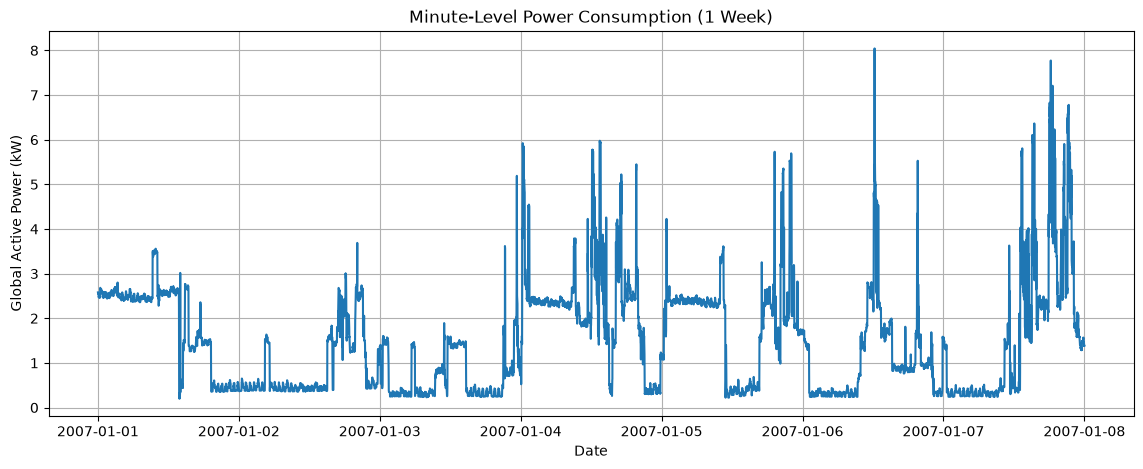

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(
    week_minute.index,
    week_minute["Global_active_power"]
)

plt.title("Minute-Level Power Consumption (1 Week)")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.grid(True)

plt.show()

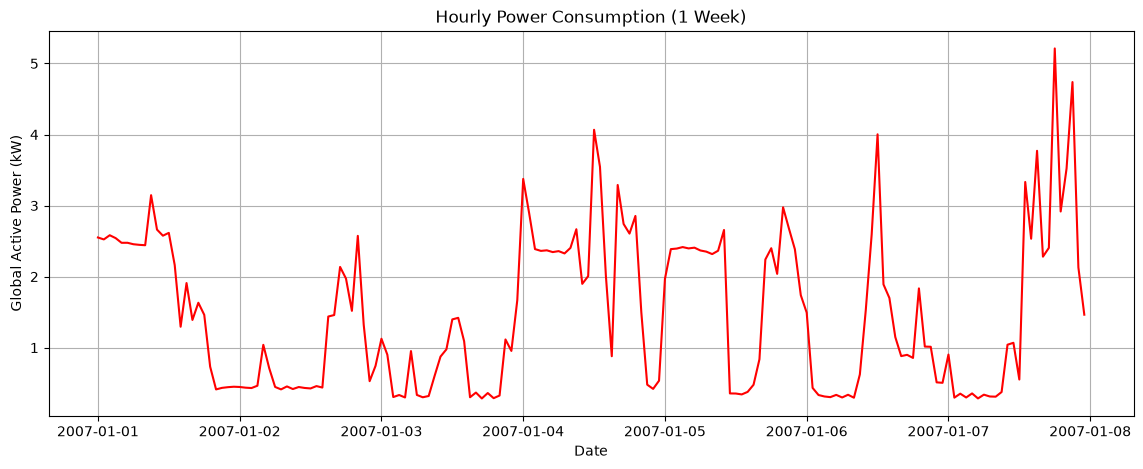

In [19]:
plt.figure(figsize=(14,5))

plt.plot(
    week_hourly.index,
    week_hourly["Global_active_power"],
    color="red"
)

plt.title("Hourly Power Consumption (1 Week)")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.grid(True)

plt.show()

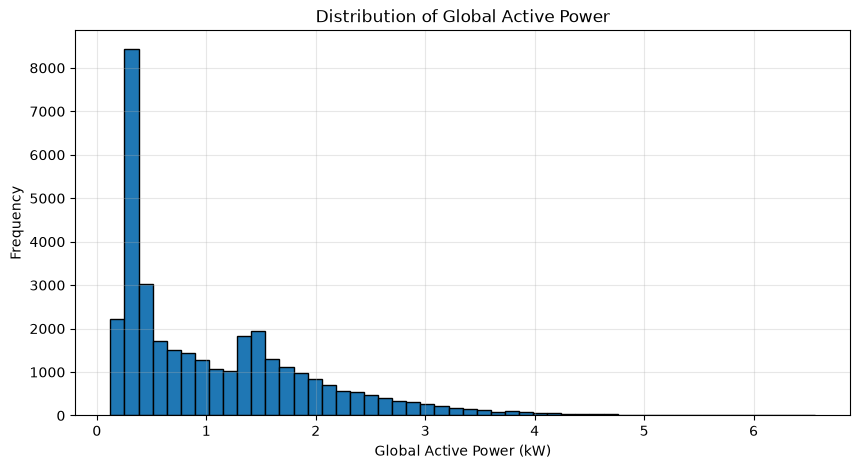

In [20]:
plt.figure(figsize=(10,5))

plt.hist(
    hourly_df["Global_active_power"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Global Active Power")
plt.xlabel("Global Active Power (kW)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

C:\Users\PAVAN TEJA\AppData\Local\Temp\ipykernel_11940\3344076651.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


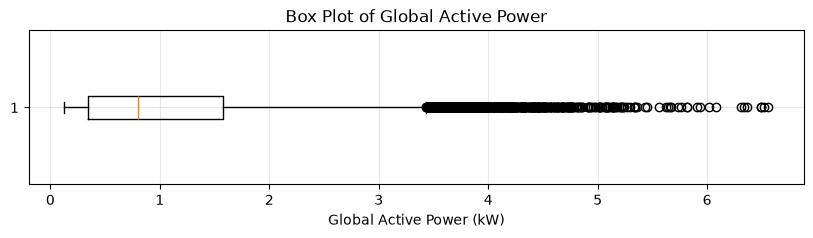

In [21]:
plt.figure(figsize=(10,2))

plt.boxplot(
    hourly_df["Global_active_power"],
    vert=False
)

plt.title("Box Plot of Global Active Power")
plt.xlabel("Global Active Power (kW)")

plt.grid(alpha=0.3)

plt.show()

In [22]:
hourly_df["Global_active_power"].describe()

count    34589.000000
mean         1.090311
std          0.894323
min          0.124000
25%          0.342867
50%          0.803267
75%          1.578700
max          6.560533
Name: Global_active_power, dtype: float64

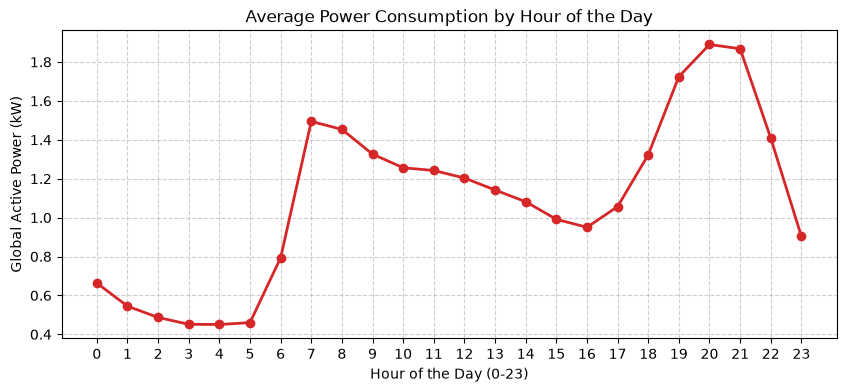

In [23]:
# Average power consumption for each hour of the day

hourly_profile = hourly_df.groupby(hourly_df.index.hour)["Global_active_power"].mean()


plt.figure(figsize=(10, 4))
plt.plot(hourly_profile.index, hourly_profile.values, marker='o', color='tab:red', linewidth=2)

plt.title("Average Power Consumption by Hour of the Day")
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Global Active Power (kW)")
plt.xticks(range(0, 24))  # Show every hour from 0 to 23
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


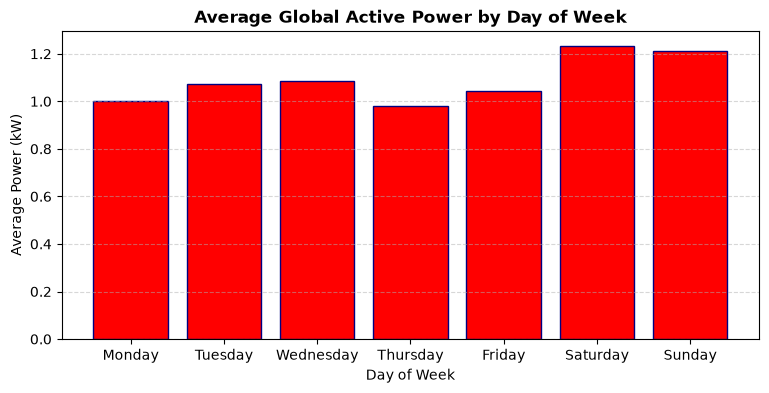

In [24]:
#  Average by day of week
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

weekly_profile = (
    hourly_df.groupby(hourly_df.index.day_name())["Global_active_power"]
    .mean()
    .reindex(day_order)
)
plt.figure(figsize=(9,4))
plt.bar(weekly_profile.index,weekly_profile.values,color="r",edgecolor="navy")
plt.title('Average Global Active Power by Day of Week', fontsize=12, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Power (kW)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

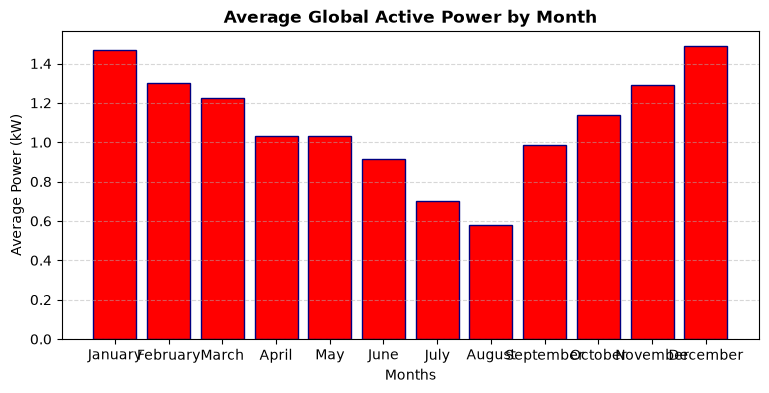

In [25]:
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]

monthly_profile = (
    hourly_df.groupby(hourly_df.index.month_name())["Global_active_power"]
    .mean()
    .reindex(month_order)
)
plt.figure(figsize=(9,4))
plt.bar(monthly_profile.index,monthly_profile.values,color="r",edgecolor="navy")
plt.title('Average Global Active Power by Month', fontsize=12, fontweight='bold')
plt.xlabel('Months')
plt.ylabel('Average Power (kW)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Feature Engineering

### Creating hour, day_of_week, month and is_weekend features since LSTM doesnot understand this information itself. We need to extract these information then train the LSTM

In [26]:
hourly_df["Hour"] = hourly_df.index.hour
hourly_df["Day_of_Week"] = hourly_df.index.dayofweek
hourly_df["Month"] = hourly_df.index.month
hourly_df["Is_Weekend"] = (
    hourly_df["Day_of_Week"]>=5
).astype(int)

In [27]:
# Verify New Features
hourly_df.head(10)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Day_of_Week,Month,Is_Weekend
datetime,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,5,12,1
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,5,12,1
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,5,12,1
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,5,12,1
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,5,12,1
2006-12-16 22:00:00,2.200133,0.056167,238.760000,9.523333,0.0,0.133333,4.433333,22,5,12,1
2006-12-16 23:00:00,2.061600,0.071433,240.619667,8.896667,0.0,0.083333,0.000000,23,5,12,1
2006-12-17 00:00:00,1.882467,0.102433,240.961833,8.126667,0.0,0.466667,0.000000,0,6,12,1
2006-12-17 01:00:00,3.349400,0.136933,240.448333,14.246667,0.0,25.233333,0.000000,1,6,12,1


In [28]:
hourly_df.index.dtype

dtype('<M8[us]')

## Lag Features implementation

lag features are used to maintain its previous behaviour. 
ie,.
- lag1 - behaviour (power consumption) one hour ago
- lag24 - behaviour 24hours ago
- lag168 - behaviour one week ago 
#### from this we can understand hours level behaviour change , day level and weekely behaviour change

In [29]:
lag_features=[1,24,168]
for lag in lag_features:
    hourly_df[f'Lag_{lag}']=hourly_df["Global_active_power"].shift(lag)

In [30]:
hourly_df[
    [
        "Global_active_power",
        "Lag_1",
        "Lag_24",
        "Lag_168"
    ]
].head(30)

,Global_active_power,Lag_1,Lag_24,Lag_168
datetime,,,,
2006-12-16 17:00:00,4.222889,NaN,NaN,NaN
2006-12-16 18:00:00,3.632200,4.222889,NaN,NaN
2006-12-16 19:00:00,3.400233,3.632200,NaN,NaN
2006-12-16 20:00:00,3.268567,3.400233,NaN,NaN
2006-12-16 21:00:00,3.056467,3.268567,NaN,NaN
2006-12-16 22:00:00,2.200133,3.056467,NaN,NaN
2006-12-16 23:00:00,2.061600,2.200133,NaN,NaN
2006-12-17 00:00:00,1.882467,2.061600,NaN,NaN
2006-12-17 01:00:00,3.349400,1.882467,NaN,NaN


In [31]:
hourly_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Day_of_Week,Month,Is_Weekend,Lag_1,Lag_24,Lag_168
datetime,,,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,5,12,1,NaN,NaN,NaN
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,5,12,1,4.222889,NaN,NaN
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,5,12,1,3.632200,NaN,NaN
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,5,12,1,3.400233,NaN,NaN
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,5,12,1,3.268567,NaN,NaN


### Rolling Statistics
Lag features gives the previous previous. 
But Rolling features tells the average behaviourial value of that window  (average power consumption of that window)

In [32]:
hourly_df['Rolling_Mean_24'] = hourly_df['Global_active_power'].rolling(window=24).mean()
hourly_df['Rolling_Std_24'] = hourly_df['Global_active_power'].rolling(window=24).std()

In [33]:
hourly_df[
['Global_active_power','Rolling_Mean_24','Rolling_Std_24']
].head(30)

,Global_active_power,Rolling_Mean_24,Rolling_Std_24
datetime,,,
2006-12-16 17:00:00,4.222889,NaN,NaN
2006-12-16 18:00:00,3.632200,NaN,NaN
2006-12-16 19:00:00,3.400233,NaN,NaN
2006-12-16 20:00:00,3.268567,NaN,NaN
2006-12-16 21:00:00,3.056467,NaN,NaN
2006-12-16 22:00:00,2.200133,NaN,NaN
2006-12-16 23:00:00,2.061600,NaN,NaN
2006-12-17 00:00:00,1.882467,NaN,NaN
2006-12-17 01:00:00,3.349400,NaN,NaN


In [34]:
hourly_df.isnull().sum()

Global_active_power        0
Global_reactive_power      0
Voltage                    0
Global_intensity           0
Sub_metering_1             0
Sub_metering_2             0
Sub_metering_3             0
Hour                       0
Day_of_Week                0
Month                      0
Is_Weekend                 0
Lag_1                      1
Lag_24                    24
Lag_168                  168
Rolling_Mean_24           23
Rolling_Std_24            23
dtype: int64

These are not data quality problems.

They are feature engineering artifacts.

#### What's the next step? 
- use forward fill
- use interpolation
- use backward fill
- any other filling method
- just drop those rows  
Here the best decision is 'just drop those rows'. why? couldn't we lose import information?  
ans : Why because filling those NAN values with any filling method can be impossible since not data there previously  
We got NAN values where our dataset not talking about that historical information. Rewriting those values with any values can mislead the model.  
You may think we loose important information if we drop those rows. But we are only removing 168 rows which is 0.5% of the total rows , so we are keeping 99.5% of original dataset information hence there will no much lose of information.

In [35]:
hourly_df=hourly_df.dropna()

In [36]:
hourly_df.isnull().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Hour                     0
Day_of_Week              0
Month                    0
Is_Weekend               0
Lag_1                    0
Lag_24                   0
Lag_168                  0
Rolling_Mean_24          0
Rolling_Std_24           0
dtype: int64

In [37]:
hourly_df.shape

(34421, 16)

### Splitting 80% - 20% in chronological order

In [38]:
split_idx = int(len(hourly_df)*0.80)

train_df = hourly_df.iloc[:split_idx]
test_df = hourly_df.iloc[split_idx:]

In [39]:
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

print("\nTrain Start:", train_df.index.min())
print("Train End  :", train_df.index.max())

print("\nTest Start :", test_df.index.min())
print("Test End   :", test_df.index.max())

Train Shape: (27536, 16)
Test Shape : (6885, 16)

Train Start: 2006-12-23 17:00:00
Train End  : 2010-02-13 00:00:00

Test Start : 2010-02-13 01:00:00
Test End   : 2010-11-26 21:00:00


In [40]:
# Target features
y_train = train_df['Global_active_power']
y_test = test_df['Global_active_power']

# Input Features
X_train = train_df.drop(columns=['Global_active_power'])
X_test = test_df.drop(columns=['Global_active_power'])

### Feature scaling

In [41]:
from sklearn.preprocessing import MinMaxScaler
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

In [42]:
X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1,1))

In [43]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

print(y_train_scaled.shape)
print(y_test_scaled.shape)

(27536, 15)
(6885, 15)
(27536, 1)
(6885, 1)


### Creating Sequence for LSTM

In [44]:
def create_sequences(X, y, time_steps):
    X_seq = []
    y_seq = []

    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])

    return np.array(X_seq), np.array(y_seq)

In [45]:
TIME_STEPS = 24

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    TIME_STEPS
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    TIME_STEPS
)

In [46]:
print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)

print("X_test_seq :", X_test_seq.shape)
print("y_test_seq :", y_test_seq.shape)

X_train_seq: (27512, 24, 15)
y_train_seq: (27512, 1)
X_test_seq : (6861, 24, 15)
y_test_seq : (6861, 1)


In [47]:
import sys

print(sys.executable)
print(sys.version)

C:\Users\PAVAN TEJA\AppData\Local\Programs\Python\Python312\python.exe
3.12.5 (tags/v3.12.5:ff3bc82, Aug  6 2024, 20:45:27) [MSC v.1940 64 bit (AMD64)]


In [48]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [49]:
import os

print(os.getcwd())

D:\projects\forecast-energy\notebooks


In [50]:
!pip --version

pip 24.2 from C:\Users\PAVAN TEJA\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip (python 3.12)



In [51]:
!python --version

Python 3.12.5


### Building LSTM Model 

In [52]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [53]:
model = Sequential()

In [54]:
# LSTM layer
model.add(
    LSTM(
        units=64,
        input_shape=(TIME_STEPS,X_train_seq.shape[2])
    )
)

C:\Users\PAVAN TEJA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [55]:
# Drop out Layer
model.add(
    Dropout(0.2)
)

In [56]:
# Dense Layer
model.add(
    Dense(32,activation='relu')
)
model.add(Dense(1))

In [57]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          20,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,593 (88.25 KB)

 Trainable params: 22,593 (88.25 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [59]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - loss: 0.0125 - mae: 0.0820 - val_loss: 0.0066 - val_mae: 0.0588
Epoch 2/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 0.0093 - mae: 0.0691 - val_loss: 0.0066 - val_mae: 0.0604
Epoch 3/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - loss: 0.0085 - mae: 0.0649 - val_loss: 0.0057 - val_mae: 0.0534
Epoch 4/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 0.0081 - mae: 0.0627 - val_loss: 0.0056 - val_mae: 0.0511
Epoch 5/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0078 - mae: 0.0614 - val_loss: 0.0055 - val_mae: 0.0512
Epoch 6/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 0.0077 - mae: 0.0603 - val_loss: 0.0053 - val_mae: 0.0499
Epoch 7/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0075 - mae: 0.0596 - val_loss: 0.0058 - val_mae: 0.0557
Epoch 8/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.0075 - mae: 0.0592 - val_loss: 0.0054 - val_mae: 0.0504
Epoch 9/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 

In [60]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

#### Training vs Validation Loss

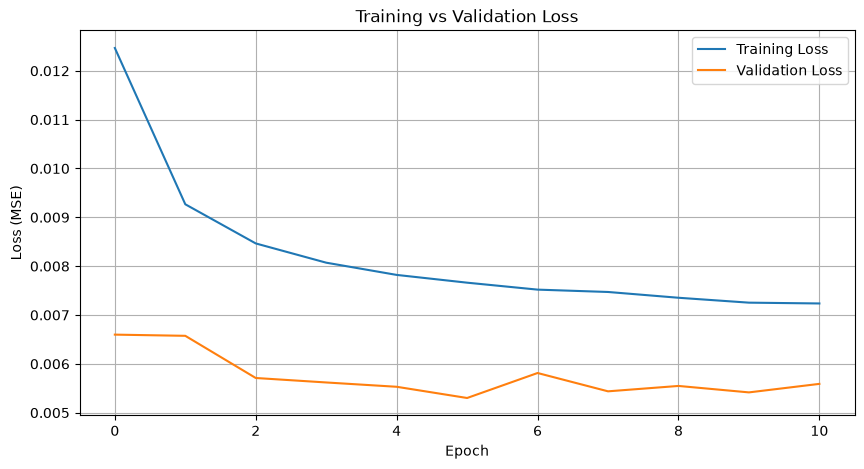

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)

plt.show()

#### Training vs Validation MAE

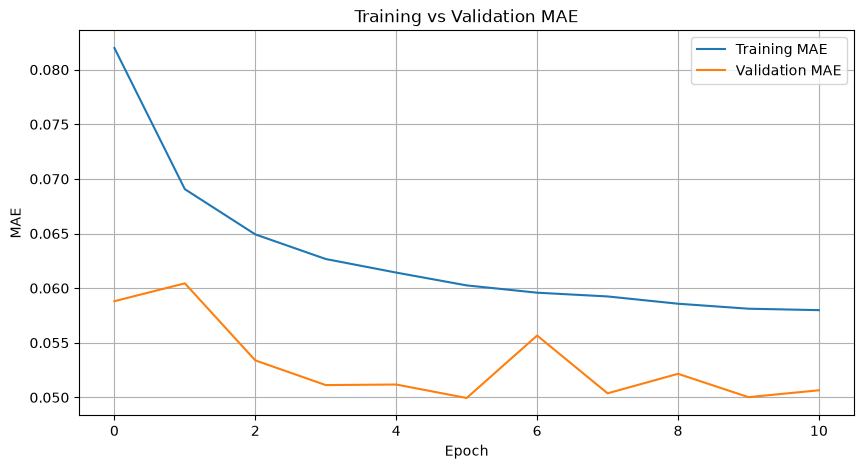

In [62]:
plt.figure(figsize=(10,5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.legend()
plt.grid(True)

plt.show()

### Evaluation

In [63]:
y_pred_scaled = model.predict(X_test_seq)

215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [64]:
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = target_scaler.inverse_transform(y_test_seq)

In [65]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 0.32146382846260935
RMSE: 0.4686216705484685
R² Score: 0.5830719332000693


In [67]:
from sklearn.metrics import mean_absolute_percentage_error

# Calculate MAPE
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"MAPE: {mape:.4f}")
print(f"MAPE (%): {mape * 100:.2f}%")

MAPE: 0.4058
MAPE (%): 40.58%


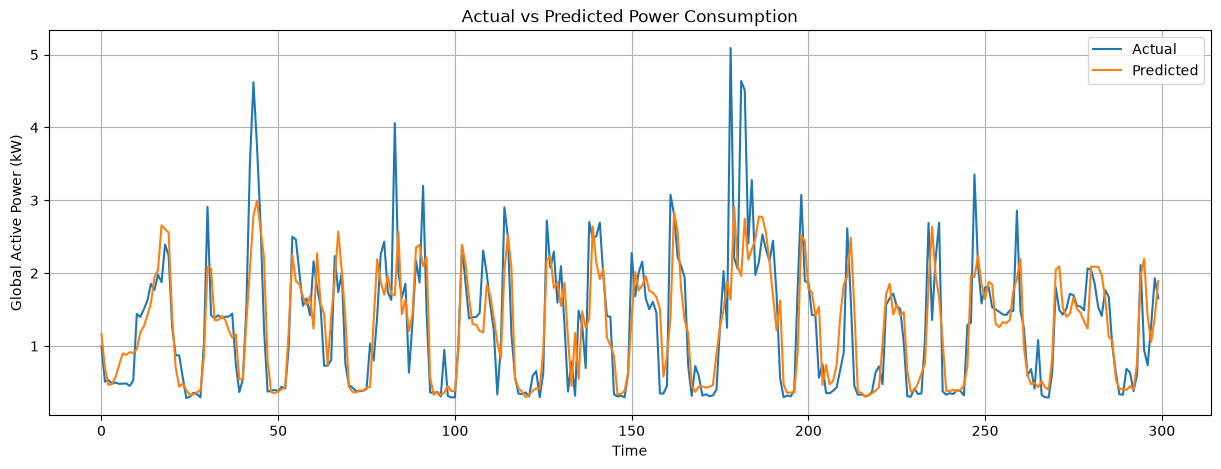

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(y_true[:300], label="Actual")
plt.plot(y_pred[:300], label="Predicted")

plt.title("Actual vs Predicted Power Consumption")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.grid(True)

plt.show()

In [76]:
import os

os.makedirs("../models", exist_ok=True)

model.save("../models/energy_forecasting_lstm.keras")

In [77]:
import joblib

joblib.dump(feature_scaler, "../models/feature_scaler.pkl")
joblib.dump(target_scaler, "../models/target_scaler.pkl")

print("Scalers saved successfully!")

Scalers saved successfully!


In [78]:
from tensorflow.keras.models import load_model

loaded_model = load_model("../models/energy_forecasting_lstm.keras")

feature_scaler_loaded = joblib.load("../models/feature_scaler.pkl")
target_scaler_loaded = joblib.load("../models/target_scaler.pkl")

print("Everything loaded successfully!")

Everything loaded successfully!
